In [2]:
!mkdir -p ~/.kaggle
!echo "KGAT_ca2e40564860831c9a588f182fb935ca" > ~/.kaggle/access_token
!chmod 600 ~/.kaggle/access_token

In [3]:
!kaggle datasets download -d ayush1220/cifar10 --unzip

Dataset URL: https://www.kaggle.com/datasets/ayush1220/cifar10
License(s): copyright-authors
100% 139M/139M [00:01<00:00, 146MB/s]



In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

In [5]:
train_ds = keras.utils.image_dataset_from_directory(
   directory="/content/cifar10/train",
    labels="inferred",
    label_mode="int",
    batch_size=64,
    image_size=(32, 32),
    shuffle=True
)

validation_ds = keras.utils.image_dataset_from_directory(
    directory="/content/cifar10/test",
    labels="inferred",
    label_mode="int",
    batch_size=64,
    image_size=(32, 32),
    shuffle=False
)

Found 50000 files belonging to 10 classes.
Found 10000 files belonging to 10 classes.


In [6]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.0417),
    tf.keras.layers.RandomCrop(32, 32)
])

In [21]:
from tensorflow.keras.layers import (
    Dense, Conv2D, MaxPooling2D, Flatten,
    Dropout, BatchNormalization
)

model = Sequential()

model.add(data_augmentation)

model.add(Conv2D(32, kernel_size=(3,3), activation='relu',
                 input_shape=(32,32,3)))
model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 10, 10, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 10, 10, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 272,170 (1.04 MB)

 Trainable params: 271,978 (1.04 MB)

 Non-trainable params: 192 (768.00 B)

In [23]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [24]:
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

In [25]:
class LearningRateLogger(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        lr = float(self.model.optimizer.learning_rate.numpy())
        print(f"Learning Rate: {lr:.6f}")

In [26]:
history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=20,
    callbacks=[lr_scheduler, LearningRateLogger()]
)

Epoch 1/20
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.2742 - loss: 2.1180Learning Rate: 0.001000
782/782 ━━━━━━━━━━━━━━━━━━━━ 129s 163ms/step - accuracy: 0.3448 - loss: 1.8187 - val_accuracy: 0.4708 - val_loss: 1.4665 - learning_rate: 0.0010
Epoch 2/20
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.4550 - loss: 1.5145Learning Rate: 0.001000
782/782 ━━━━━━━━━━━━━━━━━━━━ 125s 160ms/step - accuracy: 0.4750 - loss: 1.4575 - val_accuracy: 0.5265 - val_loss: 1.3963 - learning_rate: 0.0010
Epoch 3/20
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.5305 - loss: 1.3266Learning Rate: 0.001000
782/782 ━━━━━━━━━━━━━━━━━━━━ 147s 166ms/step - accuracy: 0.5420 - loss: 1.2918 - val_accuracy: 0.5588 - val_loss: 1.2381 - learning_rate: 0.0010
Epoch 4/20
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.5734 - loss: 1.1996Learning Rate: 0.001000
782/782 ━━━━━━━━━━━━━━━━━━━━ 125s 160ms/step - accuracy: 0.5861 - loss: 1.1722 - val_accuracy: 0.6498 - val_loss: 0.9911 

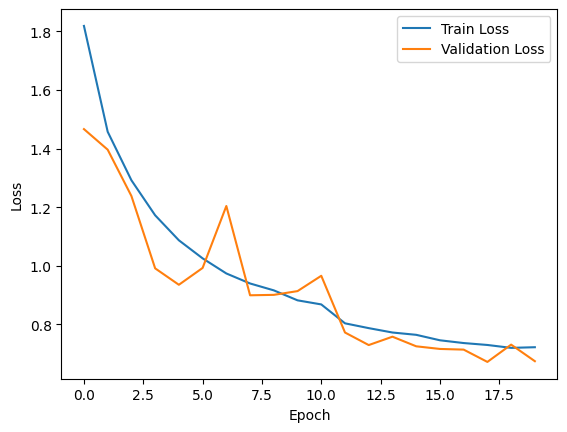

In [27]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

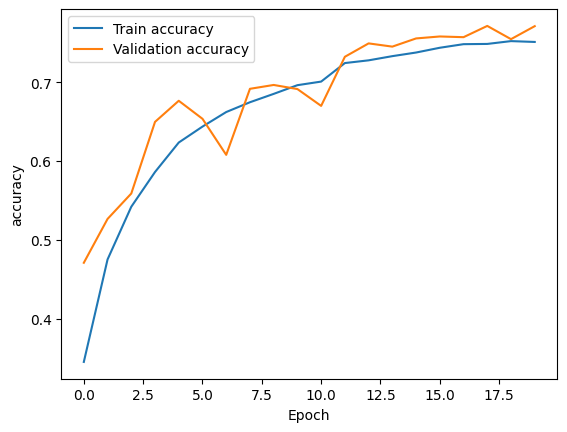

In [28]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.xlabel("Epoch")
plt.ylabel("accuracy")
plt.legend()
plt.show()

In [29]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

In [30]:
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

In [31]:
y_true = []
y_pred = []

for images, labels in validation_ds:

    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

In [32]:
y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [33]:
cm = confusion_matrix(y_true, y_pred)

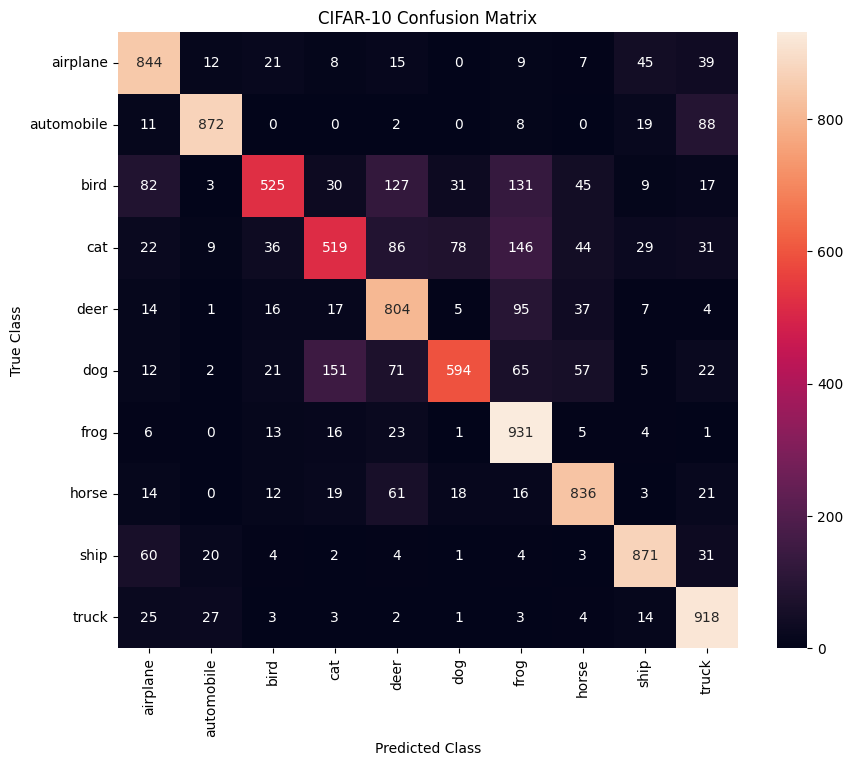

In [34]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("CIFAR-10 Confusion Matrix")

plt.show()

In [35]:
#Hence my model confuses more between classes birds, cats, dogs